In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from retrieve.get_data import get_yield

In [10]:
# ── Data ──────────────────────────────────────────────────────────────────────
term     = 5
duration = 5.0

raw_yields = get_yield(term, freq="W-FRI") / 100
dy         = raw_yields.diff().dropna()

carry     = raw_yields.shift(1).reindex(dy.index) / 52
bond_rets = carry - duration * dy

countries = bond_rets.columns.tolist()
n         = len(countries)
idx       = bond_rets.index

print(f"Assets ({n}): {countries}")
print(f"Date range: {idx.min().date()} to {idx.max().date()} ({len(idx)} weeks)")

Assets (11): ['US', 'UK', 'FRA', 'GER', 'AUS', 'INDO', 'INDIA', 'JAPAN', 'SWITZ', 'BRAZIL', 'MEXICO']
Date range: 2012-02-03 to 2026-03-13 (737 weeks)


In [11]:
# ── Benchmark weights: 70% GBI-Global (DM) + 30% GBI-EM blend ────────────────
# Approximates JPMorgan GBI-Global + GBI-EM Global Diversified
# normalised to sum to 1
benchmark_weights_raw = {
    'US':     0.30,   # largest DM government bond market
    'JAPAN':  0.19,   # second largest DM
    'GER':    0.09,   # core Eurozone
    'FRA':    0.07,   # core Eurozone
    'UK':     0.07,   # major DM
    'INDIA':  0.06,   # largest GBI-EM weight in our universe
    'MEXICO': 0.05,   # major GBI-EM member
    'SWITZ':  0.05,   # liquid DM
    'BRAZIL': 0.04,   # GBI-EM member
    'INDO':   0.04,   # GBI-EM member
    'AUS':    0.04,   # DM member
}

# ensure all countries present and normalise
total = sum(benchmark_weights_raw[c] for c in countries)
w_bench = np.array([benchmark_weights_raw[c] / total for c in countries])

print('Benchmark weights:')
for c, w in zip(countries, w_bench):
    print(f'  {c:8s}: {w:.1%}')
print(f'  Total   : {w_bench.sum():.1%}')

Benchmark weights:
  US      : 30.0%
  UK      : 7.0%
  FRA     : 7.0%
  GER     : 9.0%
  AUS     : 4.0%
  INDO    : 4.0%
  INDIA   : 6.0%
  JAPAN   : 19.0%
  SWITZ   : 5.0%
  BRAZIL  : 4.0%
  MEXICO  : 5.0%
  Total   : 100.0%


In [12]:
# ── Parameters ────────────────────────────────────────────────────────────────
p_var          = 1      # VAR lag length (AIC-optimal from testing.ipynb)
vol_lookback   = 104    # rolling vol window for signal normalisation
alpha          = 0.15   # max deviation from benchmark per country (tracking error budget)
split_date_str = "2019-01-01"
starting_portfolio = 100_000.0

In [13]:
# ── Train/test split ──────────────────────────────────────────────────────────
split_date = idx[idx >= split_date_str][0]
split_i    = idx.get_loc(split_date)
start_i    = max(split_i, p_var + 1, vol_lookback + 1)
print(f"OOS from: {split_date.date()}  |  alpha (max tilt): {alpha:.0%}")

OOS from: 2019-01-04  |  alpha (max tilt): 15%


In [14]:
# ── Walk-forward loop: Benchmark + VAR Tilt ───────────────────────────────────
# w_final = w_bench + alpha * signal
# signal[i] in [-1, 1]: normalised VAR forecast (negative = yield rises = underweight)
# alpha controls max deviation from benchmark — directly interpretable as tracking error

portfolio   = pd.Series(np.nan, index=idx)
port_bench  = pd.Series(np.nan, index=idx)   # pure benchmark (no tilt)
weights_df  = pd.DataFrame(np.nan, index=idx, columns=countries)

portfolio.iloc[start_i]  = starting_portfolio
port_bench.iloc[start_i] = starting_portfolio

for i in range(start_i, len(idx) - 1):
    end_date  = idx[i]
    next_date = idx[i + 1]

    r_next = bond_rets.loc[next_date].values

    # ── Pure benchmark (no VAR) ───────────────────────────────────────────
    port_bench.loc[next_date] = port_bench.loc[end_date] * (1.0 + float(w_bench @ r_next))

    # ── VAR(1) signal ─────────────────────────────────────────────────────
    train_var = dy.loc[:end_date].replace([np.inf, -np.inf], np.nan).dropna()
    train_var = train_var.loc[:, train_var.nunique() > 1]

    try:
        res      = VAR(train_var).fit(p_var)
        fcast    = res.forecast(y=train_var.values[-p_var:], steps=1)[0]
        names    = res.names
        roll_vol = dy.loc[:end_date].tail(vol_lookback).std()

        signal = np.zeros(n)
        for k_i, c in enumerate(countries):
            if c not in names:
                continue
            vol = roll_vol.get(c, np.nan)
            if pd.isna(vol) or vol == 0:
                continue
            # negative forecast = yield rises = underweight vs benchmark
            signal[k_i] = np.clip(-fcast[names.index(c)] / vol, -1.0, 1.0)

        # additive tilt: benchmark + alpha * signal
        w_adj = w_bench + alpha * signal
        w_adj = np.clip(w_adj, 0.0, None)   # no short positions
        w = w_adj / w_adj.sum()

    except Exception:
        w = w_bench

    weights_df.loc[end_date] = w
    portfolio.loc[next_date] = portfolio.loc[end_date] * (1.0 + float(w @ r_next))

portfolio  = portfolio.ffill()
port_bench = port_bench.ffill()
print("Done.")

Done.


In [15]:
# ── Performance ───────────────────────────────────────────────────────────────
rf_weekly = raw_yields['US'].reindex(idx) / 52

def perf(port, label):
    p    = port.loc[split_date:].dropna()
    wr   = p.pct_change().dropna()
    rf   = rf_weekly.reindex(wr.index)
    ex   = wr - rf
    sh   = (wr.mean() / wr.std(ddof=0)) * np.sqrt(52)
    exsh = (ex.mean() / ex.std(ddof=0)) * np.sqrt(52)
    tot  = p.iloc[-1] / p.iloc[0] - 1
    dd   = ((p - p.cummax()) / p.cummax()).min()
    hit  = (wr > 0).mean()
    vol  = wr.std(ddof=0) * np.sqrt(52)
    print(f"  {label:30s}  Sharpe={sh:+.2f}  ExSharpe={exsh:+.2f}  "
          f"Tot={tot:+.1%}  Vol={vol:.2%}  MaxDD={dd:.2%}  Hit={hit:.1%}")
    return wr

print(f"OOS: {split_date.date()} to {idx[-1].date()}\n")
r_active = perf(portfolio,  "Benchmark + VAR Tilt")
r_bench  = perf(port_bench, "Pure Benchmark")

# tracking error
tr_err = (r_active - r_bench.reindex(r_active.index)).std() * np.sqrt(52)
print(f"\n  Tracking error (ann.): {tr_err:.2%}")
print(f"  Information ratio    : {((r_active.mean() - r_bench.reindex(r_active.index).mean()) / (r_active - r_bench.reindex(r_active.index)).std()) * np.sqrt(52):+.2f}")

OOS: 2019-01-04 to 2026-03-13

  Benchmark + VAR Tilt            Sharpe=+0.62  ExSharpe=-0.26  Tot=+14.2%  Vol=3.03%  MaxDD=-10.34%  Hit=55.7%
  Pure Benchmark                  Sharpe=+0.53  ExSharpe=-0.36  Tot=+11.8%  Vol=3.01%  MaxDD=-10.86%  Hit=54.9%

  Tracking error (ann.): 0.52%
  Information ratio    : +0.57


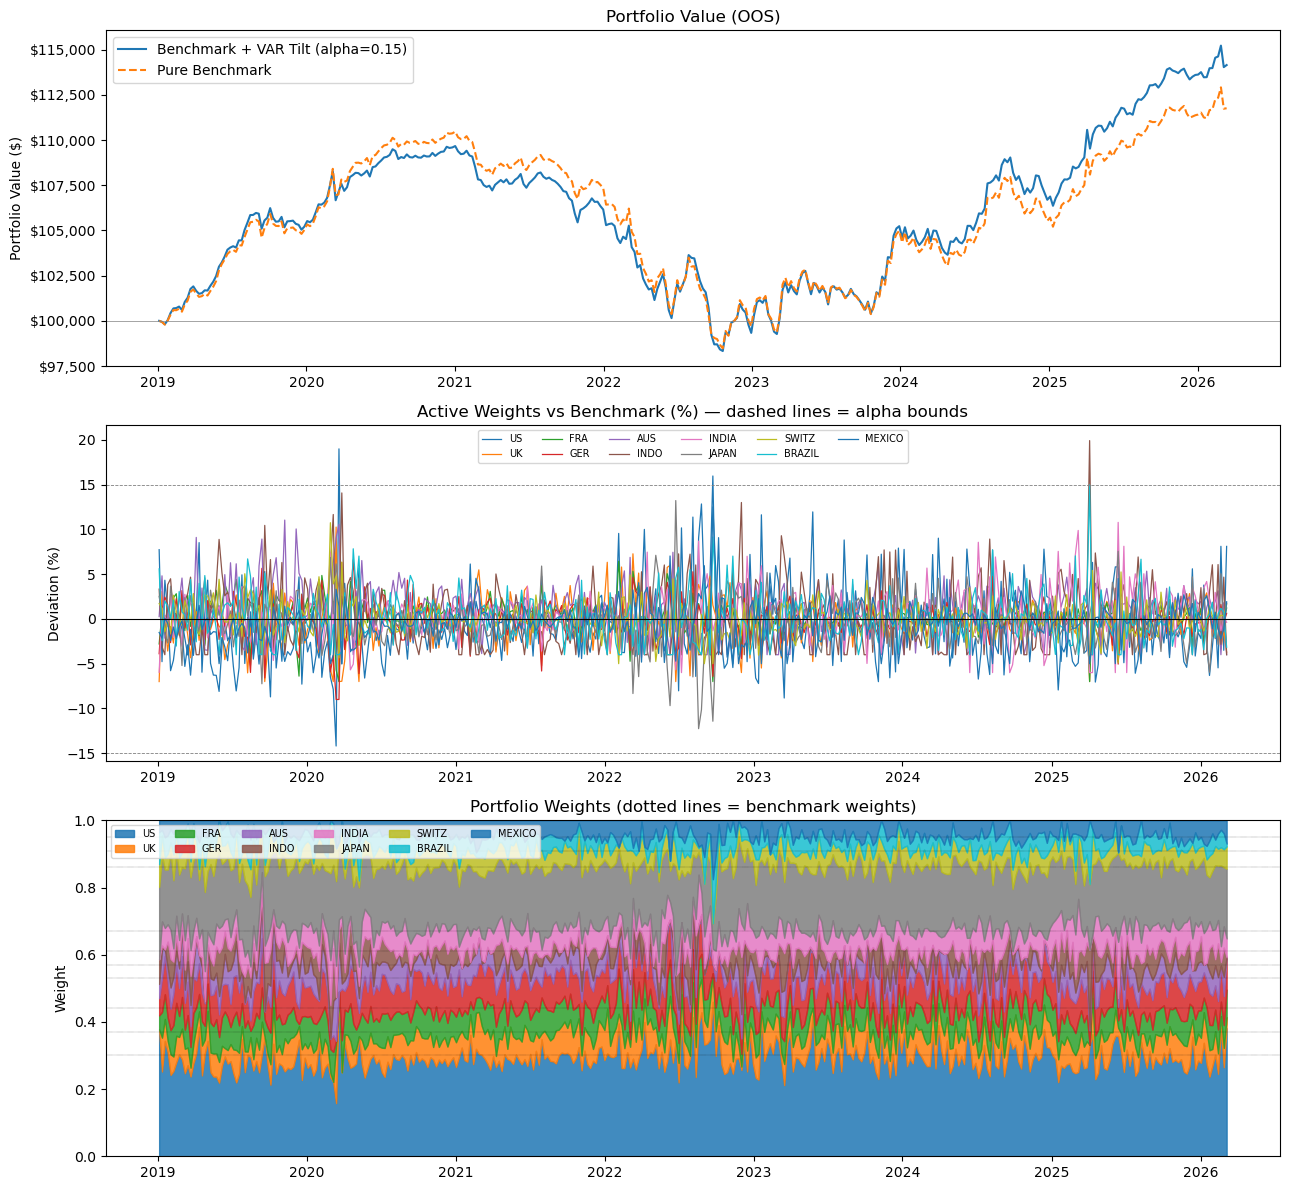

In [16]:
# ── Plots ─────────────────────────────────────────────────────────────────────
port_oos  = portfolio.loc[split_date:].dropna()
bench_oos = port_bench.loc[split_date:].dropna()
w_oos     = weights_df.loc[split_date:].dropna(how='all').astype(float)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
country_colors = {c: colors[i % len(colors)] for i, c in enumerate(countries)}

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# portfolio value
axes[0].plot(port_oos.index,  port_oos.values,  lw=1.5,        label=f"Benchmark + VAR Tilt (alpha={alpha})")
axes[0].plot(bench_oos.index, bench_oos.values, lw=1.5, ls='--', label="Pure Benchmark")
axes[0].axhline(starting_portfolio, color='grey', lw=0.5)
axes[0].set_title("Portfolio Value (OOS)")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# active weights (deviation from benchmark)
active_dev = w_oos - w_bench
for col in countries:
    axes[1].plot(active_dev.index, active_dev[col].values * 100,
                 lw=0.9, label=col, color=country_colors[col])
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axhline( alpha*100, color='grey', ls='--', lw=0.6)
axes[1].axhline(-alpha*100, color='grey', ls='--', lw=0.6)
axes[1].set_title("Active Weights vs Benchmark (%) — dashed lines = alpha bounds")
axes[1].set_ylabel("Deviation (%)")
axes[1].legend(ncol=6, fontsize=7)

# stacked benchmark + VAR weights
bottom = np.zeros(len(w_oos))
for col in countries:
    axes[2].fill_between(w_oos.index, bottom, bottom + w_oos[col].values,
                         label=col, color=country_colors[col], alpha=0.85)
    bottom += w_oos[col].fillna(0).values
# benchmark reference lines
bottom_b = 0
for col in countries:
    axes[2].axhline(bottom_b + benchmark_weights_raw[col]/total, color='black',
                    lw=0.3, ls=':')
    bottom_b += benchmark_weights_raw[col]/total
axes[2].set_ylim(0, 1)
axes[2].set_title("Portfolio Weights (dotted lines = benchmark weights)")
axes[2].set_ylabel("Weight")
axes[2].legend(ncol=6, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
# ── Alpha sweep: find optimal tracking-error budget ───────────────────────────
alphas_to_test = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]

results = []

for alpha_i in alphas_to_test:
    port_i  = pd.Series(np.nan, index=idx)
    port_i.iloc[start_i] = starting_portfolio

    for i in range(start_i, len(idx) - 1):
        end_date  = idx[i]
        next_date = idx[i + 1]
        r_next    = bond_rets.loc[next_date].values

        if alpha_i == 0.0:
            w = w_bench
        else:
            train_var = dy.loc[:end_date].replace([np.inf, -np.inf], np.nan).dropna()
            train_var = train_var.loc[:, train_var.nunique() > 1]
            try:
                res      = VAR(train_var).fit(p_var)
                fcast    = res.forecast(y=train_var.values[-p_var:], steps=1)[0]
                names    = res.names
                roll_vol = dy.loc[:end_date].tail(vol_lookback).std()
                signal   = np.zeros(n)
                for k_i, c in enumerate(countries):
                    if c not in names:
                        continue
                    vol = roll_vol.get(c, np.nan)
                    if pd.isna(vol) or vol == 0:
                        continue
                    signal[k_i] = np.clip(-fcast[names.index(c)] / vol, -1.0, 1.0)
                w_adj = w_bench + alpha_i * signal
                w_adj = np.clip(w_adj, 0.0, None)
                w     = w_adj / w_adj.sum() if w_adj.sum() > 0 else w_bench
            except Exception:
                w = w_bench

        port_i.loc[next_date] = port_i.loc[end_date] * (1.0 + float(w @ r_next))

    port_i = port_i.ffill()
    p_oos  = port_i.loc[split_date:].dropna()
    wr     = p_oos.pct_change().dropna()
    rf     = rf_weekly.reindex(wr.index)
    ex     = wr - rf
    b_oos  = port_bench.loc[split_date:].dropna()
    b_wr   = b_oos.pct_change().dropna()
    diff   = wr - b_wr.reindex(wr.index)

    sh    = (wr.mean() / wr.std(ddof=0)) * np.sqrt(52)
    exsh  = (ex.mean() / ex.std(ddof=0)) * np.sqrt(52)
    tot   = p_oos.iloc[-1] / p_oos.iloc[0] - 1
    dd    = ((p_oos - p_oos.cummax()) / p_oos.cummax()).min()
    te    = diff.std() * np.sqrt(52)
    ir    = (diff.mean() / diff.std()) * np.sqrt(52) if diff.std() > 0 else 0.0

    results.append(dict(alpha=alpha_i, sharpe=sh, ex_sharpe=exsh,
                        total_ret=tot, max_dd=dd, tracking_err=te, info_ratio=ir))
    print(f'alpha={alpha_i:.2f}  Sharpe={sh:+.2f}  ExSharpe={exsh:+.2f}  '
          f'Tot={tot:+.1%}  TE={te:.2%}  IR={ir:+.2f}')

sweep_df = pd.DataFrame(results).set_index('alpha')
print('\nBest by Sharpe:',       sweep_df['sharpe'].idxmax())
print('Best by Excess Sharpe:', sweep_df['ex_sharpe'].idxmax())
print('Best by Info Ratio:',    sweep_df['info_ratio'].idxmax())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Alpha Sweep — Benchmark + VAR Tilt', fontsize=13)

metrics = [
    ('sharpe',       'Sharpe Ratio (ann.)'),
    ('ex_sharpe',    'Excess Sharpe (ann.)'),
    ('total_ret',    'Total Return'),
    ('max_dd',       'Max Drawdown'),
    ('tracking_err', 'Tracking Error (ann.)'),
    ('info_ratio',   'Information Ratio'),
]

for ax, (col, title) in zip(axes.flat, metrics):
    vals   = sweep_df[col].values
    best_i = vals.argmax() if col not in ('max_dd', 'tracking_err') else vals.argmin()
    ax.plot(sweep_df.index, vals, 'o-', lw=1.5)
    ax.axvline(sweep_df.index[best_i], color='red',   ls='--', lw=0.8,
               label=f'best={sweep_df.index[best_i]:.2f}')
    ax.axvline(0.15,                   color='green', ls=':',  lw=0.8, label='current=0.15')
    ax.set_title(title)
    ax.set_xlabel('alpha')
    ax.legend(fontsize=7)
    if col in ('total_ret', 'max_dd', 'tracking_err'):
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.tight_layout()
plt.show()
